# Brain MRI Tissue Segmentation — Multi-Class Semantic Segmentation
## VGG19 + UNet++ | 4-Class (Background / CSF / Grey Matter / White Matter) | MRBrainS18 Dataset

**Dataset:** MRBrainS18 Challenge Dataset — 7 labeled training subjects, multi-sequence MRI (T1, FLAIR, IR). Only the `training` split is used since the `test` split has no publicly released segmentation labels.

**Label Remapping:** MRBrainS18 uses 9 classes which are consolidated into 4 tissue classes:
- 0 → Background
- 1, 2, 8 → Grey Matter (cortical GM + basal ganglia + brainstem/cerebellum)
- 3, 4 → White Matter (WM + WM lesions)
- 5, 6, 7 → CSF (ventricular CSF + vessels + external CSF)

**Training Notes:**
- Only 7 labeled subjects are available; therefore, every slice (`step=1`) is used to maximize the training dataset.
- Strong data augmentation is applied to improve model generalization.
- EarlyStopping is disabled so the model trains for the full configured number of epochs.

## 1. Import Libraries

In [9]:
import os
import cv2
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Input, Conv2D, UpSampling2D, concatenate,
    BatchNormalization, Dropout, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import VGG19
from tensorflow.keras import callbacks
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import time
import datetime

!pip install nibabel -q
import nibabel as nib

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

In [10]:
# ─── Paths ────────────────────────────────────────────────────────────────────
TRAIN_ROOT = '/kaggle/input/datasets/maheswarimudadla/training/training'
# Note: test split excluded — no public segmentation labels available

PROCESSED_DIR  = 'mrbrains_processed'
IMAGE_FOLDER   = os.path.join(PROCESSED_DIR, 'images')
MASK_FOLDER    = os.path.join(PROCESSED_DIR, 'masks')
TRAIN_IMG_DIR  = os.path.join(PROCESSED_DIR, 'train', 'images')
TRAIN_MASK_DIR = os.path.join(PROCESSED_DIR, 'train', 'masks')
TEST_IMG_DIR   = os.path.join(PROCESSED_DIR, 'test',  'images')
TEST_MASK_DIR  = os.path.join(PROCESSED_DIR, 'test',  'masks')

# ─── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 8    # smaller batch — fewer total slices than OASIS/IBSR
EPOCHS      = 100
SEED        = 42
TEST_SPLIT  = 0.20  # slightly larger test split given small dataset
NUM_CLASSES = 4
CLASS_NAMES = ['Background', 'CSF', 'Grey Matter', 'White Matter']

# ─── MRBrainS18 label remapping ───────────────────────────────────────────────
# Original 9 classes → 4 standard tissue classes (matches OASIS-1 and IBSR)
MRBRAINS_REMAP = {
    0: 0,  # Background
    1: 2,  # Cortical Grey Matter → GM
    2: 2,  # Basal Ganglia → GM
    3: 3,  # White Matter → WM
    4: 3,  # White Matter Lesions → WM
    5: 1,  # Ventricular CSF → CSF
    6: 1,  # Vessels/Choroid Plexus → CSF
    7: 1,  # External CSF/Sulci → CSF
    8: 2,  # Brainstem + Cerebellum → GM
}

print('Config set ✓')
print('Label remapping:', MRBRAINS_REMAP)

Config set ✓
Label remapping: {0: 0, 1: 2, 2: 2, 3: 3, 4: 3, 5: 1, 6: 1, 7: 1, 8: 2}


## 3. Extract 2D Slices — Remap 9 Classes to 4

In [11]:
for d in [IMAGE_FOLDER, MASK_FOLDER,
          TRAIN_IMG_DIR, TRAIN_MASK_DIR,
          TEST_IMG_DIR,  TEST_MASK_DIR]:
    os.makedirs(d, exist_ok=True)

print('Directories ready ✓')

Directories ready ✓


In [12]:
import os
import shutil
import cv2
import nibabel as nib
import numpy as np
from tqdm import tqdm


def normalize_slice(arr):
    mn, mx = arr.min(), arr.max()
    if mx - mn == 0:
        return np.zeros_like(arr, dtype=np.uint8)
    return ((arr - mn) / (mx - mn) * 255).astype(np.uint8)


def remap_labels(seg_arr, remap_dict):
    """Remap integer label array using a dictionary mapping."""
    out = np.zeros_like(seg_arr, dtype=np.uint8)
    for orig_label, new_label in remap_dict.items():
        out[seg_arr == orig_label] = new_label
    return out


def extract_slices_mrbrains(subject_dir, subject_name, img_out, mask_out, step=1):
    """
    Extract aligned T1 and segmentation slices from MRBrainS18.

    Uses reg_T1.nii because it is already registered to segm.nii.
    Both volumes have shape (240, 240, 48).
    """

    # Candidate paths for registered T1
    t1_candidates = [
        os.path.join(subject_dir, "orig", "reg_T1.nii"),
        os.path.join(subject_dir, "orig", "reg_T1.nii.gz"),
        os.path.join(subject_dir, "pre", "reg_T1.nii"),
        os.path.join(subject_dir, "pre", "reg_T1.nii.gz"),
    ]

    t1_path = None
    for p in t1_candidates:
        if os.path.exists(p):
            t1_path = p
            break

    # Segmentation
    seg_candidates = [
        os.path.join(subject_dir, "segm.nii"),
        os.path.join(subject_dir, "segm.nii.gz"),
    ]

    seg_path = None
    for p in seg_candidates:
        if os.path.exists(p):
            seg_path = p
            break

    if t1_path is None or seg_path is None:
        print(f"Skipping {subject_name} (missing reg_T1 or segm)")
        return 0

    # Load volumes
    brain_vol = np.squeeze(nib.load(t1_path).get_fdata())
    seg_vol = np.squeeze(nib.load(seg_path).get_fdata())

    print(f"{subject_name}")
    print(f"  T1 : {brain_vol.shape}")
    print(f"  Seg: {seg_vol.shape}")

    # Safety check
    if brain_vol.shape != seg_vol.shape:
        print(f"Shape mismatch in {subject_name}, skipping.")
        return 0

    saved = 0

    for i in range(0, brain_vol.shape[2], step):

        brain_slice = brain_vol[:, :, i]
        seg_slice = seg_vol[:, :, i]

        # Skip completely empty MRI slices
        if np.max(brain_slice) == 0:
            continue

        img_arr = normalize_slice(brain_slice)

        mask_arr = remap_labels(
            np.round(seg_slice).astype(np.uint8),
            MRBRAINS_REMAP
        )

        filename = f"{subject_name}_sl{i:03d}.png"

        cv2.imwrite(
            os.path.join(img_out, filename),
            img_arr
        )

        cv2.imwrite(
            os.path.join(mask_out, filename),
            mask_arr
        )

        saved += 1

    return saved


# ---------------------------------------------------------
# Remove previous extracted dataset
# ---------------------------------------------------------

for folder in [IMAGE_FOLDER, MASK_FOLDER]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder, exist_ok=True)


# ---------------------------------------------------------
# Extract slices from all training subjects
# ---------------------------------------------------------

subject_folders = sorted([
    d for d in os.listdir(TRAIN_ROOT)
    if os.path.isdir(os.path.join(TRAIN_ROOT, d))
])

print(f"Found {len(subject_folders)} training subjects:")
print(subject_folders)
print()

total_slices = 0

for subj_name in tqdm(subject_folders, desc="Extracting slices"):

    subj_dir = os.path.join(TRAIN_ROOT, subj_name)

    total_slices += extract_slices_mrbrains(
        subj_dir,
        subj_name,
        IMAGE_FOLDER,
        MASK_FOLDER,
        step=1
    )

print("\nExtraction Complete!")
print(f"Total slices extracted : {total_slices}")
print(f"Images saved           : {len(os.listdir(IMAGE_FOLDER))}")
print(f"Masks saved            : {len(os.listdir(MASK_FOLDER))}")

Found 7 training subjects:
['1', '14', '27', '29', '4', '5', '7']



Extracting slices:   0%|          | 0/7 [00:00<?, ?it/s]

1
  T1 : (240, 240, 48)
  Seg: (240, 240, 48)


Extracting slices:  14%|█▍        | 1/7 [00:00<00:00,  9.02it/s]

14
  T1 : (240, 240, 48)
  Seg: (240, 240, 48)


...

4
  T1 : (240, 240, 48)
  Seg: (240, 240, 48)


Extracting slices:  86%|████████▌ | 6/7 [00:00<00:00,  8.97it/s]

5
  T1 : (240, 240, 48)
  Seg: (240, 240, 48)


Extracting slices: 100%|██████████| 7/7 [00:00<00:00,  8.92it/s]

7
  T1 : (240, 240, 48)
  Seg: (240, 240, 48)

Extraction Complete!
Total slices extracted : 336
Images saved           : 336
Masks saved            : 336


In [13]:
import os
import nibabel as nib

subj = os.path.join(TRAIN_ROOT, "1")

for root, dirs, files in os.walk(subj):
    for f in files:
        if f.endswith(".nii") or f.endswith(".nii.gz"):
            path = os.path.join(root, f)
            img = nib.load(path)
            print(f"{path}")
            print("shape:", img.shape)
            print()

/kaggle/input/datasets/maheswarimudadla/training/training/1/segm.nii
shape: (240, 240, 48)

/kaggle/input/datasets/maheswarimudadla/training/training/1/pre/IR.nii
shape: (240, 240, 48)

/kaggle/input/datasets/maheswarimudadla/training/training/1/pre/T1.nii
shape: (256, 256, 192)

/kaggle/input/datasets/maheswarimudadla/training/training/1/pre/FLAIR.nii
shape: (240, 240, 48)

/kaggle/input/datasets/maheswarimudadla/training/training/1/pre/reg_IR.nii
shape: (240, 240, 48)

/kaggle/input/datasets/maheswarimudadla/training/training/1/pre/reg_T1.nii
shape: (240, 240, 48)

/kaggle/input/datasets/maheswarimudadla/training/training/1/orig/T1_mask.nii
shape: (256, 256, 192)

/kaggle/input/datasets/maheswarimudadla/training/training/1/orig/IR.nii
shape: (240, 240, 48)

/kaggle/input/datasets/maheswarimudadla/training/training/1/orig/T1.nii
shape: (256, 256, 192)

/kaggle/input/datasets/maheswarimudadla/training/training/1/orig/FLAIR.nii
shape: (240, 240, 48)

/kaggle/input/datasets/maheswarimuda

## 4. Verify Label Remapping & Visualize

In [14]:
sample_mask_files = random.sample(os.listdir(MASK_FOLDER), min(20, len(os.listdir(MASK_FOLDER))))
all_vals = set()
for f in sample_mask_files:
    m = cv2.imread(os.path.join(MASK_FOLDER, f), cv2.IMREAD_GRAYSCALE)
    all_vals.update(np.unique(m).tolist())

print('Unique label values found across sample masks:', sorted(all_vals))
print('Expected: [0, 1, 2, 3]  (Background, CSF, Grey Matter, White Matter)')

Unique label values found across sample masks: [0, 1, 2, 3]
Expected: [0, 1, 2, 3]  (Background, CSF, Grey Matter, White Matter)


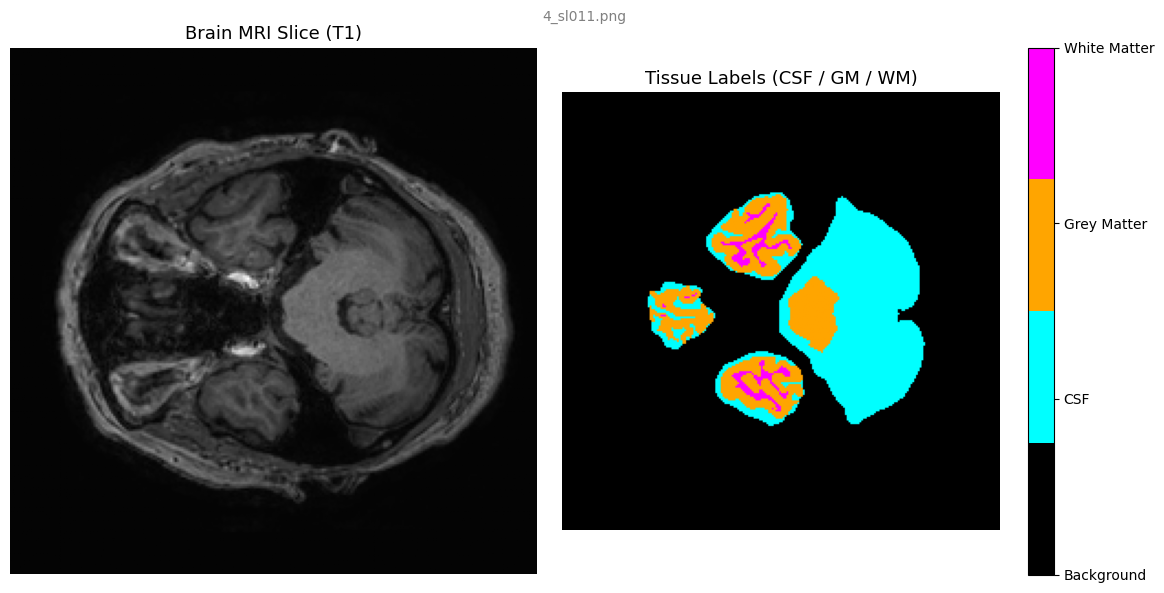

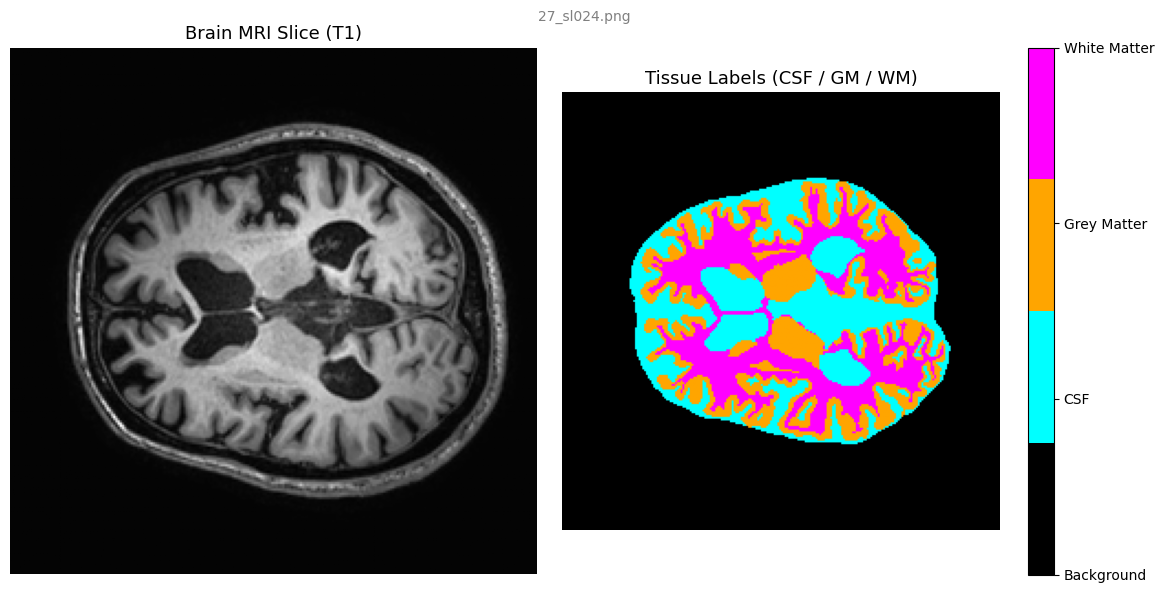

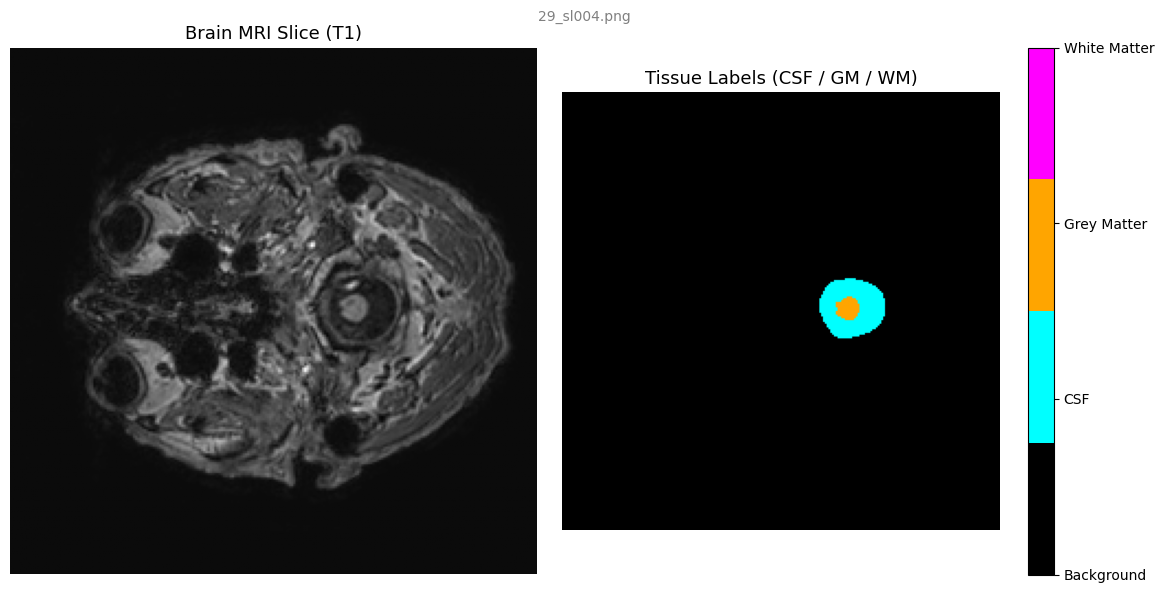

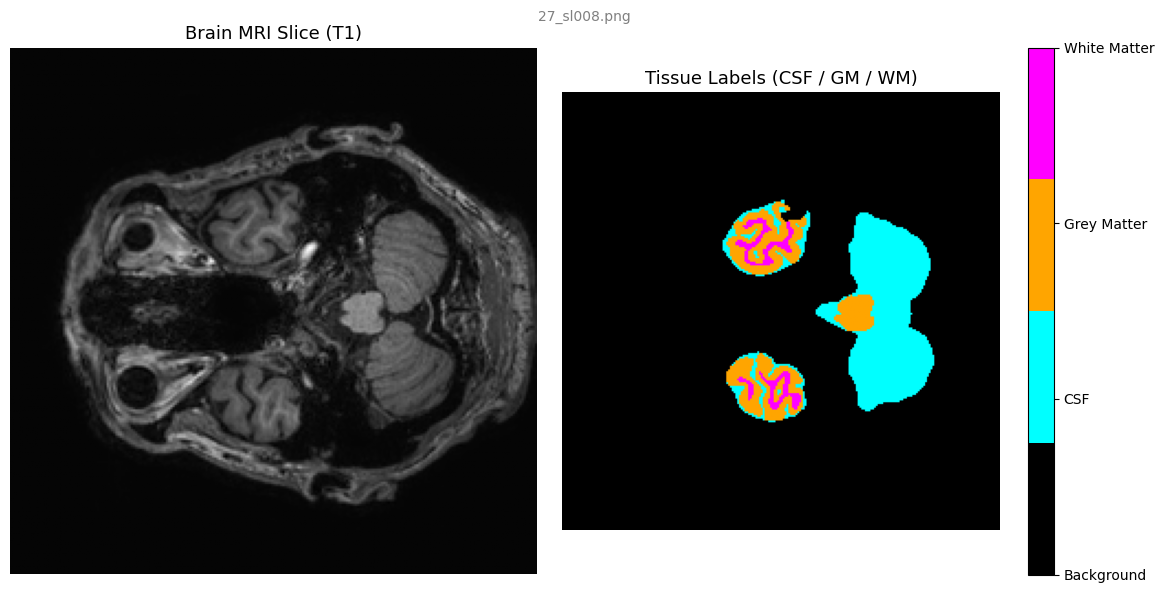

In [15]:
CLASS_COLORS = ['black', 'cyan', 'orange', 'magenta']
cmap_classes = mcolors.ListedColormap(CLASS_COLORS)

def visualize_sample(image_name):
    img  = cv2.imread(os.path.join(IMAGE_FOLDER, image_name), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(os.path.join(MASK_FOLDER,  image_name), cv2.IMREAD_GRAYSCALE)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Brain MRI Slice (T1)', fontsize=13)

    im = axes[1].imshow(mask, cmap=cmap_classes, vmin=0, vmax=NUM_CLASSES - 1)
    axes[1].set_title('Tissue Labels (CSF / GM / WM)', fontsize=13)
    cbar = plt.colorbar(im, ax=axes[1], ticks=range(NUM_CLASSES))
    cbar.ax.set_yticklabels(CLASS_NAMES)

    for ax in axes: ax.axis('off')
    plt.suptitle(image_name, fontsize=10, color='gray')
    plt.tight_layout()
    plt.show()


all_images = os.listdir(IMAGE_FOLDER)
for _ in range(4):
    visualize_sample(random.choice(all_images))

## 5. Train / Test Split

In [16]:
images = sorted([f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.png')])
masks  = sorted([f for f in os.listdir(MASK_FOLDER)  if f.endswith('.png')])

assert images == masks, 'Image-mask mismatch!'

train_imgs, test_imgs = train_test_split(images, test_size=TEST_SPLIT, random_state=SEED)
print(f'Train: {len(train_imgs)}  |  Test: {len(test_imgs)}')

def copy_files(file_list, src_img, src_mask, dst_img, dst_mask):
    for f in tqdm(file_list, leave=False):
        shutil.copy(os.path.join(src_img,  f), os.path.join(dst_img,  f))
        shutil.copy(os.path.join(src_mask, f), os.path.join(dst_mask, f))

copy_files(train_imgs, IMAGE_FOLDER, MASK_FOLDER, TRAIN_IMG_DIR, TRAIN_MASK_DIR)
copy_files(test_imgs,  IMAGE_FOLDER, MASK_FOLDER, TEST_IMG_DIR,  TEST_MASK_DIR)
print('Files copied ✓')

Train: 268  |  Test: 68


Files copied ✓


## 6. tf.data Pipeline — with stronger augmentation (small dataset)

In [17]:
def load_image(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method='bilinear')
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')
    mask = tf.cast(mask, tf.int32)
    mask = tf.squeeze(mask, axis=-1)
    mask = tf.one_hot(mask, depth=NUM_CLASSES)
    mask = tf.cast(mask, tf.float32)
    return img, mask


def augment(img, mask):
    # Stronger augmentation since dataset is small (7 subjects)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, mask


def build_dataset(img_dir, mask_dir, augment_data=False, batch=BATCH_SIZE):
    img_files  = sorted([os.path.join(img_dir,  f) for f in os.listdir(img_dir)  if f.endswith('.png')])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.png')])
    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds


train_dataset = build_dataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, augment_data=True)
test_dataset  = build_dataset(TEST_IMG_DIR,  TEST_MASK_DIR,  augment_data=False)

print('Datasets ready ✓')
for imgs, masks in train_dataset.take(1):
    print('Batch shapes → images:', imgs.shape, ' masks:', masks.shape)

I0000 00:00:1783353775.630567      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Datasets ready ✓
Batch shapes → images: (8, 224, 224, 3)  masks: (8, 224, 224, 4)


## 7. Model — VGG19 Encoder + UNet++ (Nested) Decoder, 4-class softmax output
**Combines VGG19's deeper encoder with UNet++'s dense nested skip pathways.**

In [18]:
def conv_block(x, filters, name_prefix):
    x = Conv2D(filters, (3,3), padding='same', name=f'{name_prefix}_c1')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn1')(x)
    x = Activation('relu', name=f'{name_prefix}_act1')(x)
    x = Conv2D(filters, (3,3), padding='same', name=f'{name_prefix}_c2')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn2')(x)
    x = Activation('relu', name=f'{name_prefix}_act2')(x)
    return x

def up(x, name): return UpSampling2D((2,2), name=name)(x)

def build_model(input_shape=(224,224,3), num_classes=4, freeze_encoder=True):
    inputs = Input(shape=input_shape, name='input')
    base = VGG19(include_top=False, weights='imagenet', input_tensor=inputs)
    if freeze_encoder:
        for layer in base.layers: layer.trainable = False
    X00=base.get_layer('block1_conv2').output
    X10=base.get_layer('block2_conv2').output
    X20=base.get_layer('block3_conv4').output
    X30=base.get_layer('block4_conv4').output
    X40=base.get_layer('block5_conv4').output
    F=[64,128,256,512,512]
    X01=conv_block(concatenate([X00,up(X10,'up10_01')]),F[0],'X01')
    X11=conv_block(concatenate([X10,up(X20,'up20_11')]),F[1],'X11')
    X21=conv_block(concatenate([X20,up(X30,'up30_21')]),F[2],'X21')
    X31=conv_block(concatenate([X30,up(X40,'up40_31')]),F[3],'X31')
    X02=conv_block(concatenate([X00,X01,up(X11,'up11_02')]),F[0],'X02')
    X12=conv_block(concatenate([X10,X11,up(X21,'up21_12')]),F[1],'X12')
    X22=conv_block(concatenate([X20,X21,up(X31,'up31_22')]),F[2],'X22')
    X03=conv_block(concatenate([X00,X01,X02,up(X12,'up12_03')]),F[0],'X03')
    X13=conv_block(concatenate([X10,X11,X12,up(X22,'up22_13')]),F[1],'X13')
    X04=conv_block(concatenate([X00,X01,X02,X03,up(X13,'up13_04')]),F[0],'X04')
    output=Conv2D(num_classes,(1,1),activation='softmax',name='output')(X04)
    return Model(inputs=inputs,outputs=output,name='VGG19_UNetPP_MultiClass_MRBrainS18')

model=build_model(input_shape=(*IMG_SIZE,3),num_classes=NUM_CLASSES)
print('Model built')
print(f'Total parameters     : {model.count_params():,}')
print(f'Trainable parameters : {sum([K.count_params(w) for w in model.trainable_weights]):,}')

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Model built
Total parameters     : 35,450,436
Trainable parameters : 15,419,396


## 8. Custom Metrics & Loss

In [19]:
def dice_coefficient_multiclass(y_true, y_pred, smooth=1.0):
    y_true_f = K.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = K.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    union = K.sum(y_true_f, axis=0) + K.sum(y_pred_f, axis=0)
    return K.mean((2.0 * intersection + smooth) / (union + smooth))

def dice_loss_multiclass(y_true, y_pred):
    return 1.0 - dice_coefficient_multiclass(y_true, y_pred)

def iou_score_multiclass(y_true, y_pred, smooth=1.0):
    y_true_f = K.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = K.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    total = K.sum(y_true_f, axis=0) + K.sum(y_pred_f, axis=0) - intersection
    return K.mean((intersection + smooth) / (total + smooth))

def csf_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 1]; p = y_pred[..., 1]
    i = K.sum(t * p)
    return (i + smooth) / (K.sum(t) + K.sum(p) - i + smooth)

def gm_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 2]; p = y_pred[..., 2]
    i = K.sum(t * p)
    return (i + smooth) / (K.sum(t) + K.sum(p) - i + smooth)

def wm_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 3]; p = y_pred[..., 3]
    i = K.sum(t * p)
    return (i + smooth) / (K.sum(t) + K.sum(p) - i + smooth)

def pixel_accuracy_multiclass(y_true, y_pred):
    return K.mean(K.cast(K.equal(K.argmax(y_true, axis=-1), K.argmax(y_pred, axis=-1)), K.floatx()))

def combined_loss_multiclass(y_true, y_pred):
    return dice_loss_multiclass(y_true, y_pred) + tf.keras.losses.categorical_crossentropy(y_true, y_pred)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss_multiclass,
    metrics=[dice_coefficient_multiclass, iou_score_multiclass,
             pixel_accuracy_multiclass, csf_iou, gm_iou, wm_iou]
)
print('Model compiled ✓')

Model compiled ✓


## 9. Model Summary

In [20]:
model.summary()
try:
    tf.keras.utils.plot_model(model, to_file='vgg19_unetpp_mrbrains_architecture.png',
                               show_shapes=True, show_layer_names=True, dpi=64)
    print('Architecture diagram saved ✓')
except Exception as e:
    print('Architecture plot skipped:', str(e)[:100])

Model: "VGG19_UNetPP_MultiClass_MRBrainS18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv4        │ (None, 56, 56,    │    590,080 │ block3_conv3[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv4[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv4        │ (None, 28, 28,    │  2,359,808 │ block4_conv3[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv4[0][

 Total params: 35,450,436 (135.23 MB)

 Trainable params: 15,419,396 (58.82 MB)

 Non-trainable params: 20,031,040 (76.41 MB)

"dot" with args ['-Tpng', '/tmp/tmpoojivxdj/tmpoubkdj8c'] returned code: -6

stdout, stderr:
 b''
b"failed at node 6830[0]\ndot: maze.c:311: chkSgraph: Assertion `np->cells[0]' failed.\n"

Architecture plot skipped: "dot" with args ['-Tpng', '/tmp/tmpoojivxdj/tmpoubkdj8c'] returned code: -6


## 10. Callbacks (EarlyStopping disabled)

In [21]:
def decode_mask(onehot_mask):
    return tf.argmax(onehot_mask, axis=-1)

def colorize_mask(label_map):
    colors = np.array([[0,0,0],[0,255,255],[255,165,0],[255,0,255]], dtype=np.uint8)
    return colors[np.array(label_map).astype(int)]

def show_predictions(dataset, num=3, model_to_use=None):
    m = model_to_use or model
    for imgs, masks in dataset.take(1):
        preds = m.predict(imgs, verbose=0)
        for i in range(min(num, len(imgs))):
            fig, axes = plt.subplots(1, 3, figsize=(13, 4))
            axes[0].imshow(imgs[i].numpy());                              axes[0].set_title('Input MRI')
            axes[1].imshow(colorize_mask(decode_mask(masks[i]).numpy())); axes[1].set_title('Ground Truth')
            axes[2].imshow(colorize_mask(decode_mask(preds[i]).numpy())); axes[2].set_title('Prediction')
            for ax in axes: ax.axis('off')
            plt.tight_layout(); plt.show()

class DisplayCallback(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            show_predictions(test_dataset, num=2)
            print(f'Prediction after epoch {epoch + 1}\n')

logdir = os.path.join('logs', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

callbacks_list = [
    DisplayCallback(),
    callbacks.TensorBoard(logdir, histogram_freq=1),
    callbacks.ModelCheckpoint('best_model_vgg19unetpp_mrbrains.keras', verbose=1,
                               save_best_only=True, monitor='val_iou_score_multiclass', mode='max'),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    # EarlyStopping intentionally removed
]
print('Callbacks ready ✓ (no EarlyStopping — will run all', EPOCHS, 'epochs)')

Callbacks ready ✓ (no EarlyStopping — will run all 100 epochs)


## 11. Initial Predictions (before training)

Predictions before training:


I0000 00:00:1783353802.501927     150 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


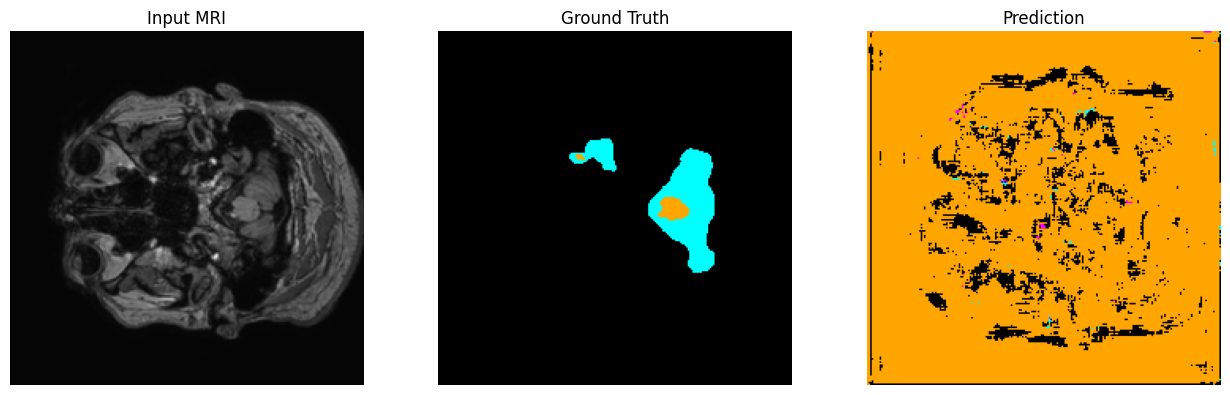

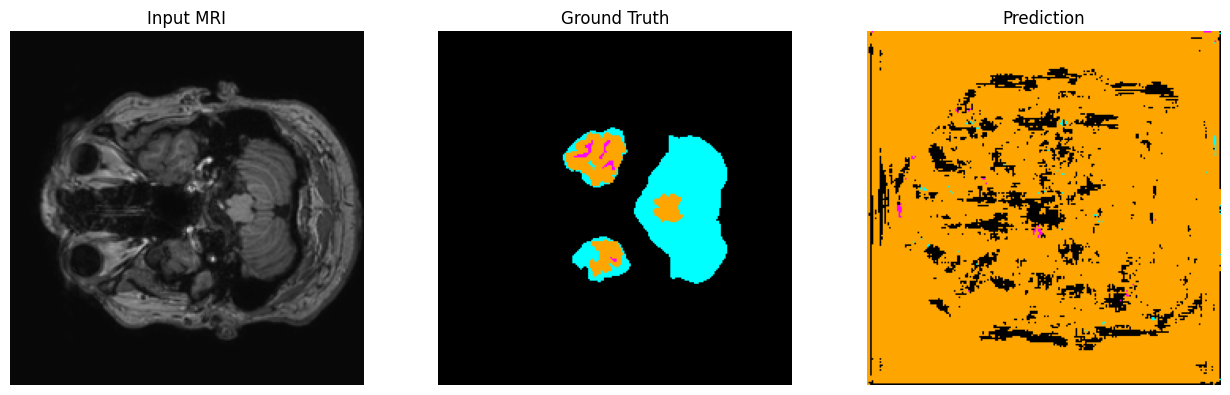

In [22]:
print('Predictions before training:')
show_predictions(test_dataset, num=2)

## 12. Training

Steps per epoch  : 33
Validation steps : 8
Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - csf_iou: 0.1165 - dice_coefficient_multiclass: 0.3018 - gm_iou: 0.1236 - iou_score_multiclass: 0.2016 - loss: 1.7465 - pixel_accuracy_multiclass: 0.6814 - wm_iou: 0.1110
Epoch 1: val_iou_score_multiclass improved from None to 0.09512, saving model to best_model_vgg19unetpp_mrbrains.keras

Epoch 1: finished saving model to best_model_vgg19unetpp_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 68s 727ms/step - csf_iou: 0.1578 - dice_coefficient_multiclass: 0.3740 - gm_iou: 0.1654 - iou_score_multiclass: 0.2625 - loss: 1.4099 - pixel_accuracy_multiclass: 0.8121 - wm_iou: 0.1537 - val_csf_iou: 0.0655 - val_dice_coefficient_multiclass: 0.1720 - val_gm_iou: 0.1128 - val_iou_score_multiclass: 0.0951 - val_loss: 4.4458 - val_pixel_accuracy_multiclass: 0.2184 - val_wm_iou: 0.0686 - learning_rate: 1.0000e-04
Epoch 2/100


2026-07-06 16:04:37.159610: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 16:04:37.405252: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 16:04:40.436467: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 16:04:40.695337: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 16:04:44.139104: E external/local_xla/xla/stream_

 1/33 ━━━━━━━━━━━━━━━━━━━━ 16:59 32s/step - csf_iou: 0.0160 - dice_coefficient_multiclass: 0.1859 - gm_iou: 4.9806e-04 - iou_score_multiclass: 0.1420 - loss: 1.8566 - pixel_accuracy_multiclass: 0.9418 - wm_iou: 3.4501e-05
Epoch 2: val_iou_score_multiclass improved from 0.09512 to 0.09975, saving model to best_model_vgg19unetpp_mrbrains.keras

Epoch 2: finished saving model to best_model_vgg19unetpp_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 40s 263ms/step - csf_iou: 0.0160 - dice_coefficient_multiclass: 0.1859 - gm_iou: 4.9806e-04 - iou_score_multiclass: 0.1420 - loss: 1.8566 - pixel_accuracy_multiclass: 0.9418 - wm_iou: 3.4501e-05 - val_csf_iou: 0.0705 - val_dice_coefficient_multiclass: 0.1796 - val_gm_iou: 0.1128 - val_iou_score_multiclass: 0.0997 - val_loss: 4.0969 - val_pixel_accuracy_multiclass: 0.2294 - val_wm_iou: 0.0728 - learning_rate: 1.0000e-04
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - csf_iou: 0.2579 - dice_coefficient_multiclass: 0.4935 - gm_iou: 0.2486 - iou_s

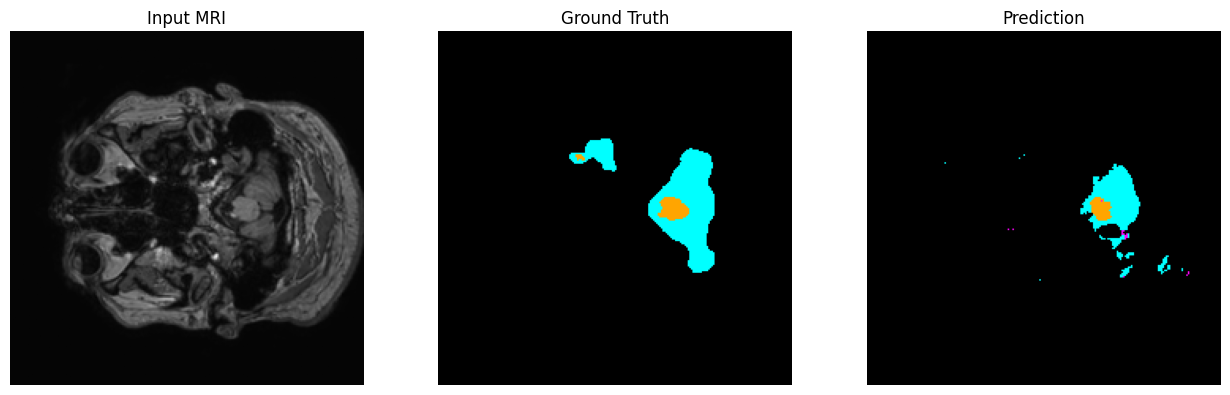

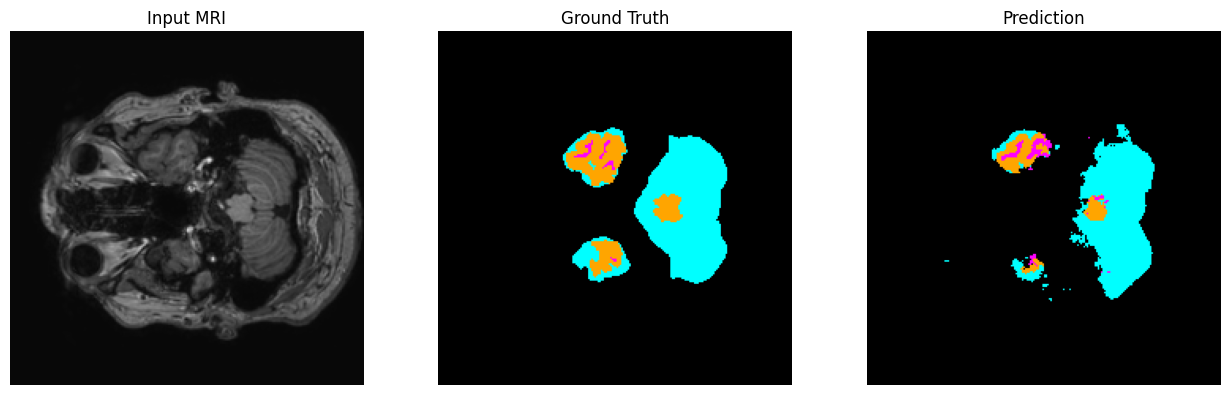

Prediction after epoch 10


Epoch 10: val_iou_score_multiclass did not improve from 0.37998
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 242ms/step - csf_iou: 0.0861 - dice_coefficient_multiclass: 0.2654 - gm_iou: 9.5730e-04 - iou_score_multiclass: 0.2267 - loss: 0.9885 - pixel_accuracy_multiclass: 0.9965 - wm_iou: 8.8642e-05 - val_csf_iou: 0.3007 - val_dice_coefficient_multiclass: 0.5241 - val_gm_iou: 0.2679 - val_iou_score_multiclass: 0.3782 - val_loss: 0.8743 - val_pixel_accuracy_multiclass: 0.9520 - val_wm_iou: 0.2433 - learning_rate: 1.0000e-04
Epoch 11/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - csf_iou: 0.4740 - dice_coefficient_multiclass: 0.6570 - gm_iou: 0.4210 - iou_score_multiclass: 0.5390 - loss: 0.5224 - pixel_accuracy_multiclass: 0.9609 - wm_iou: 0.3626
Epoch 11: val_iou_score_multiclass improved from 0.37998 to 0.46121, saving model to best_model_vgg19unetpp_mrbrains.keras

Epoch 11: finished saving model to best_model_vgg19unetpp_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 603ms

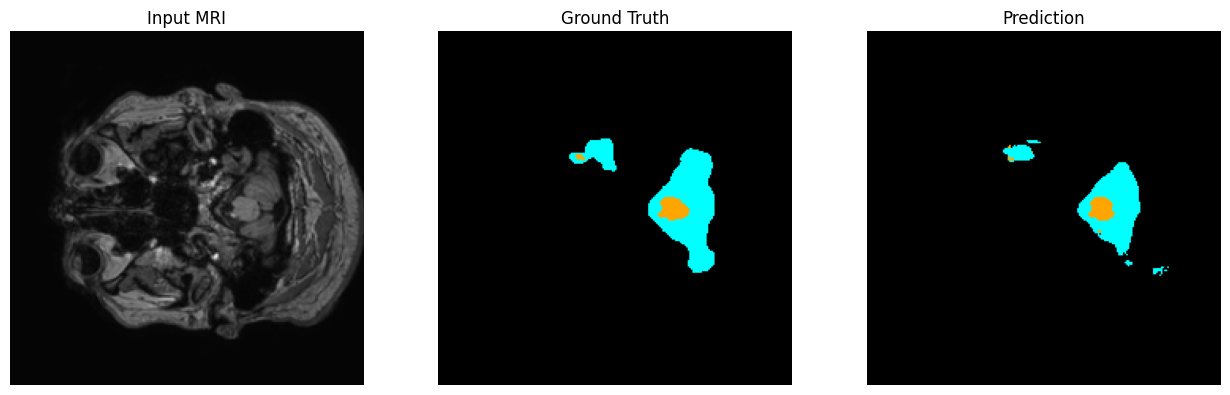

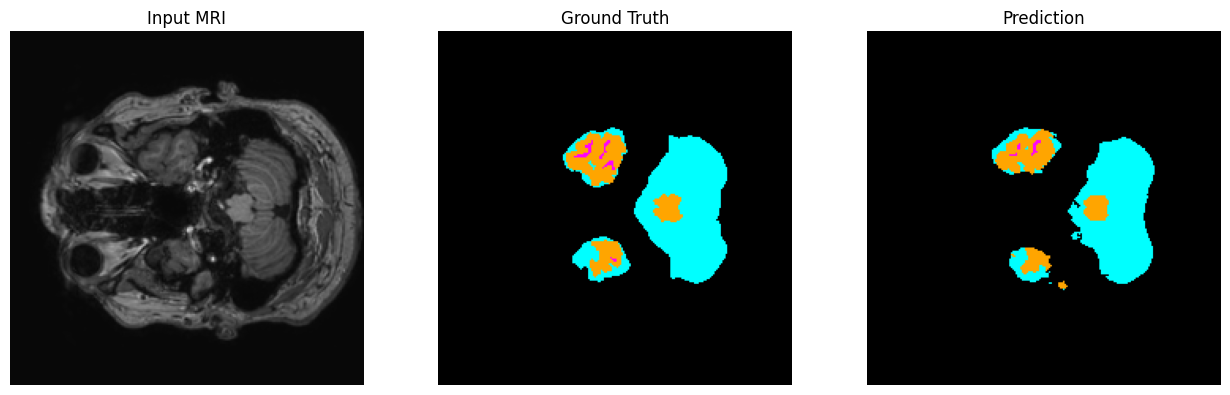

Prediction after epoch 20


Epoch 20: val_iou_score_multiclass did not improve from 0.64291
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 237ms/step - csf_iou: 0.1451 - dice_coefficient_multiclass: 0.3007 - gm_iou: 0.0012 - iou_score_multiclass: 0.2615 - loss: 0.8122 - pixel_accuracy_multiclass: 0.9982 - wm_iou: 1.6431e-04 - val_csf_iou: 0.5733 - val_dice_coefficient_multiclass: 0.7703 - val_gm_iou: 0.5350 - val_iou_score_multiclass: 0.6423 - val_loss: 0.3680 - val_pixel_accuracy_multiclass: 0.9650 - val_wm_iou: 0.5330 - learning_rate: 1.0000e-04
Epoch 21/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - csf_iou: 0.5737 - dice_coefficient_multiclass: 0.7234 - gm_iou: 0.5031 - iou_score_multiclass: 0.6122 - loss: 0.4048 - pixel_accuracy_multiclass: 0.9671 - wm_iou: 0.4320
Epoch 21: val_iou_score_multiclass improved from 0.64291 to 0.65767, saving model to best_model_vgg19unetpp_mrbrains.keras

Epoch 21: finished saving model to best_model_vgg19unetpp_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 605ms/ste

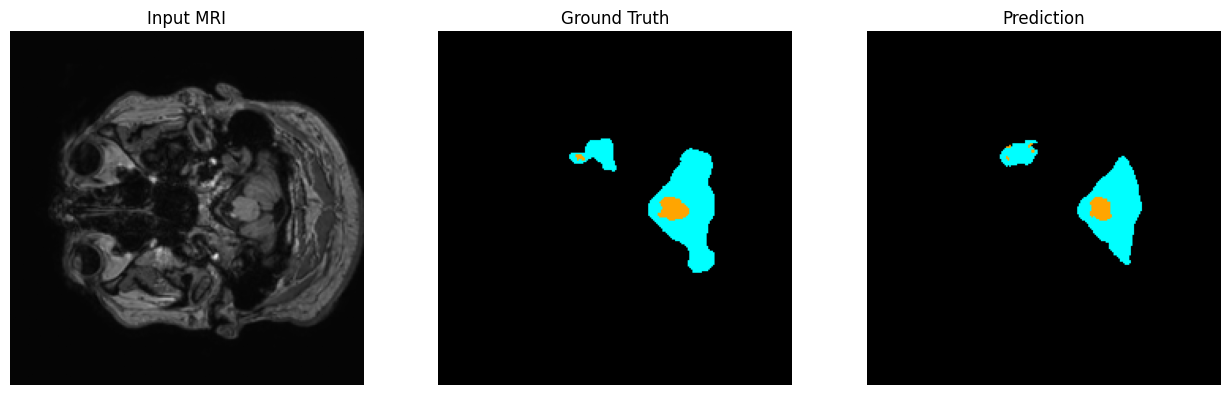

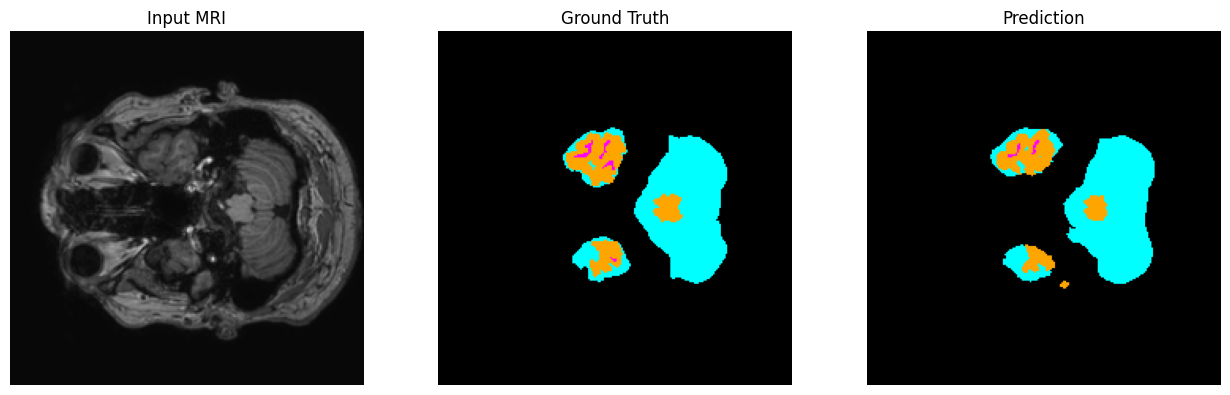

Prediction after epoch 30


Epoch 30: val_iou_score_multiclass did not improve from 0.70508
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 242ms/step - csf_iou: 0.2000 - dice_coefficient_multiclass: 0.3251 - gm_iou: 0.0011 - iou_score_multiclass: 0.2833 - loss: 0.7510 - pixel_accuracy_multiclass: 0.9984 - wm_iou: 2.6263e-04 - val_csf_iou: 0.6451 - val_dice_coefficient_multiclass: 0.8179 - val_gm_iou: 0.6039 - val_iou_score_multiclass: 0.7042 - val_loss: 0.3029 - val_pixel_accuracy_multiclass: 0.9653 - val_wm_iou: 0.6124 - learning_rate: 1.0000e-04
Epoch 31/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - csf_iou: 0.6290 - dice_coefficient_multiclass: 0.7633 - gm_iou: 0.5590 - iou_score_multiclass: 0.6572 - loss: 0.3430 - pixel_accuracy_multiclass: 0.9695 - wm_iou: 0.4809
Epoch 31: val_iou_score_multiclass improved from 0.70508 to 0.72018, saving model to best_model_vgg19unetpp_mrbrains.keras

Epoch 31: finished saving model to best_model_vgg19unetpp_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 604ms/ste

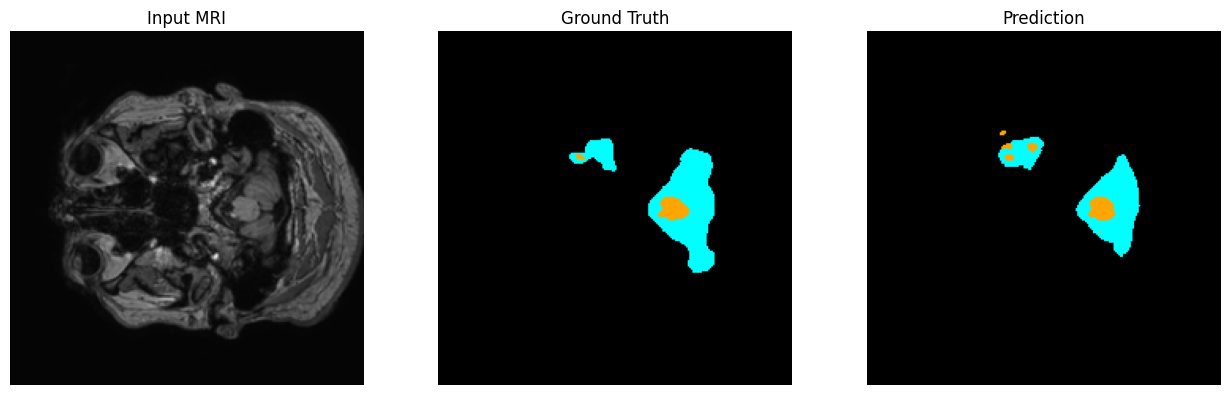

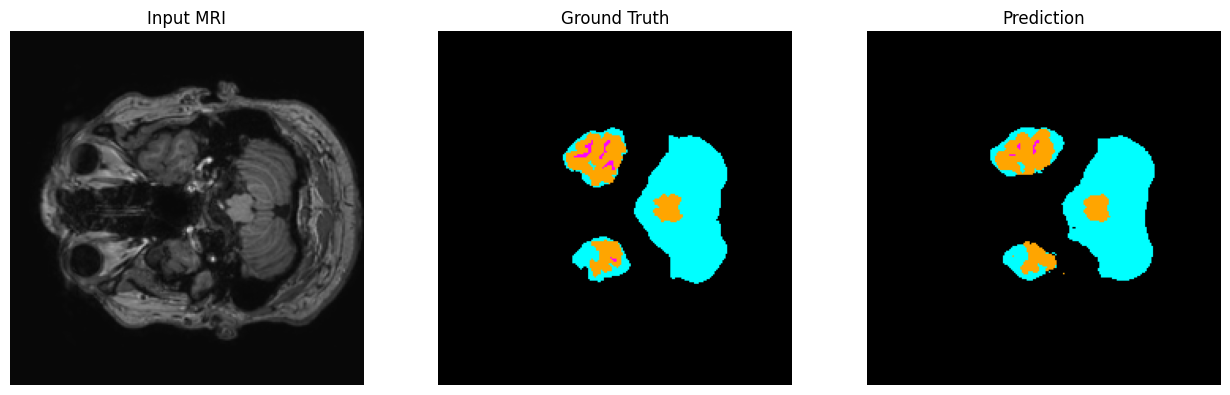

Prediction after epoch 40


Epoch 40: val_iou_score_multiclass did not improve from 0.74072
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 245ms/step - csf_iou: 0.2729 - dice_coefficient_multiclass: 0.3535 - gm_iou: 0.0044 - iou_score_multiclass: 0.3080 - loss: 0.6963 - pixel_accuracy_multiclass: 0.9987 - wm_iou: 3.8610e-04 - val_csf_iou: 0.6747 - val_dice_coefficient_multiclass: 0.8386 - val_gm_iou: 0.6439 - val_iou_score_multiclass: 0.7332 - val_loss: 0.2696 - val_pixel_accuracy_multiclass: 0.9667 - val_wm_iou: 0.6436 - learning_rate: 5.0000e-05
Epoch 41/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - csf_iou: 0.6678 - dice_coefficient_multiclass: 0.7898 - gm_iou: 0.6025 - iou_score_multiclass: 0.6884 - loss: 0.3013 - pixel_accuracy_multiclass: 0.9719 - wm_iou: 0.5137
Epoch 41: val_iou_score_multiclass did not improve from 0.74072
33/33 ━━━━━━━━━━━━━━━━━━━━ 19s 570ms/step - csf_iou: 0.6633 - dice_coefficient_multiclass: 0.7870 - gm_iou: 0.5871 - iou_score_multiclass: 0.6855 - loss: 0.3067 - pixel_accu

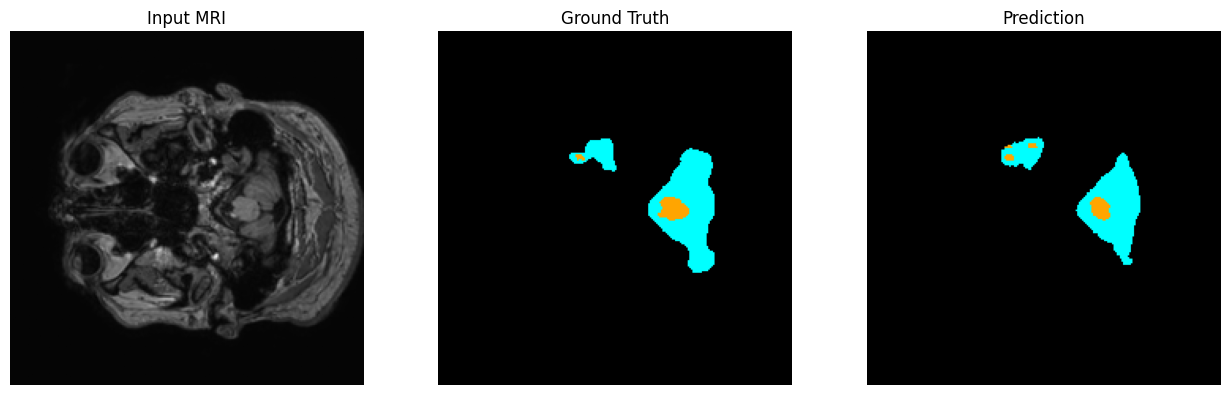

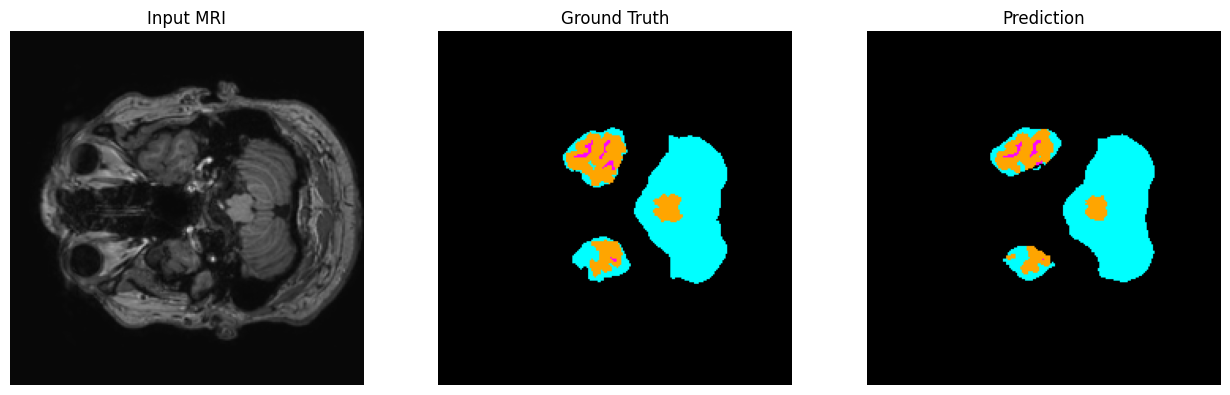

Prediction after epoch 50


Epoch 50: val_iou_score_multiclass did not improve from 0.75788
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step - csf_iou: 0.3137 - dice_coefficient_multiclass: 0.3665 - gm_iou: 0.0041 - iou_score_multiclass: 0.3198 - loss: 0.6758 - pixel_accuracy_multiclass: 0.9992 - wm_iou: 4.4852e-04 - val_csf_iou: 0.6900 - val_dice_coefficient_multiclass: 0.8561 - val_gm_iou: 0.6579 - val_iou_score_multiclass: 0.7573 - val_loss: 0.2378 - val_pixel_accuracy_multiclass: 0.9702 - val_wm_iou: 0.7089 - learning_rate: 2.5000e-05
Epoch 51/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - csf_iou: 0.6901 - dice_coefficient_multiclass: 0.8027 - gm_iou: 0.6197 - iou_score_multiclass: 0.7037 - loss: 0.2814 - pixel_accuracy_multiclass: 0.9736 - wm_iou: 0.5318
Epoch 51: val_iou_score_multiclass improved from 0.75788 to 0.75800, saving model to best_model_vgg19unetpp_mrbrains.keras

Epoch 51: finished saving model to best_model_vgg19unetpp_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 602ms/ste

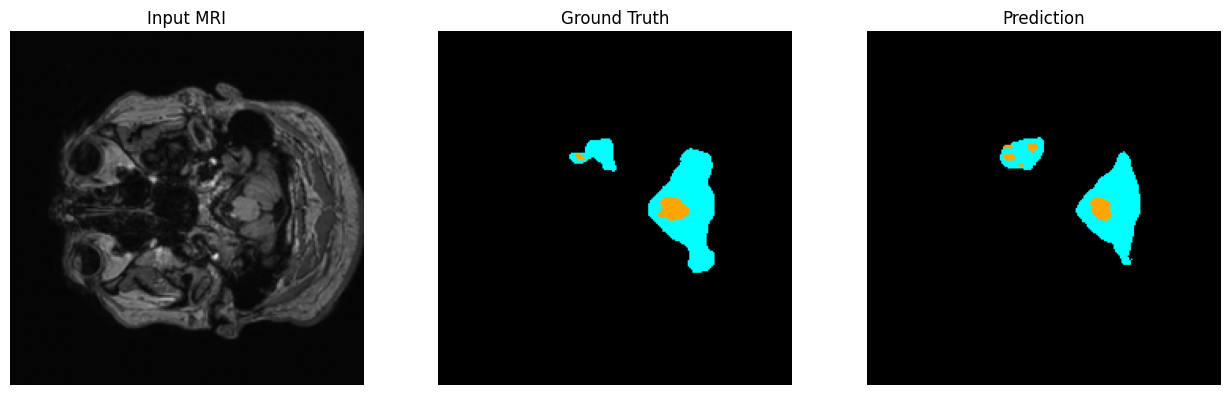

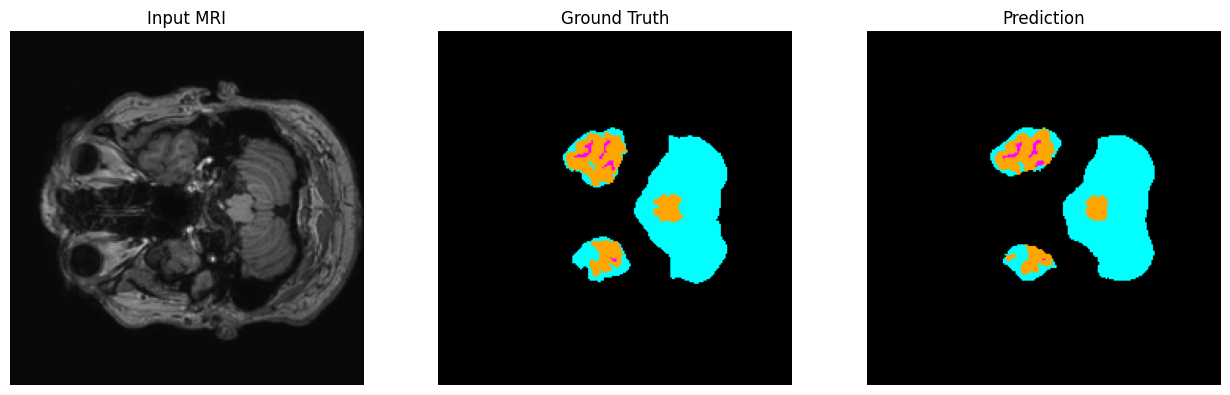

Prediction after epoch 60


Epoch 60: val_iou_score_multiclass did not improve from 0.76399
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 257ms/step - csf_iou: 0.3343 - dice_coefficient_multiclass: 0.3732 - gm_iou: 0.0048 - iou_score_multiclass: 0.3261 - loss: 0.6635 - pixel_accuracy_multiclass: 0.9994 - wm_iou: 5.0131e-04 - val_csf_iou: 0.6982 - val_dice_coefficient_multiclass: 0.8605 - val_gm_iou: 0.6651 - val_iou_score_multiclass: 0.7637 - val_loss: 0.2316 - val_pixel_accuracy_multiclass: 0.9708 - val_wm_iou: 0.7172 - learning_rate: 2.5000e-05
Epoch 61/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - csf_iou: 0.7025 - dice_coefficient_multiclass: 0.8111 - gm_iou: 0.6329 - iou_score_multiclass: 0.7138 - loss: 0.2693 - pixel_accuracy_multiclass: 0.9743 - wm_iou: 0.5444
Epoch 61: val_iou_score_multiclass improved from 0.76399 to 0.76454, saving model to best_model_vgg19unetpp_mrbrains.keras

Epoch 61: finished saving model to best_model_vgg19unetpp_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 602ms/ste

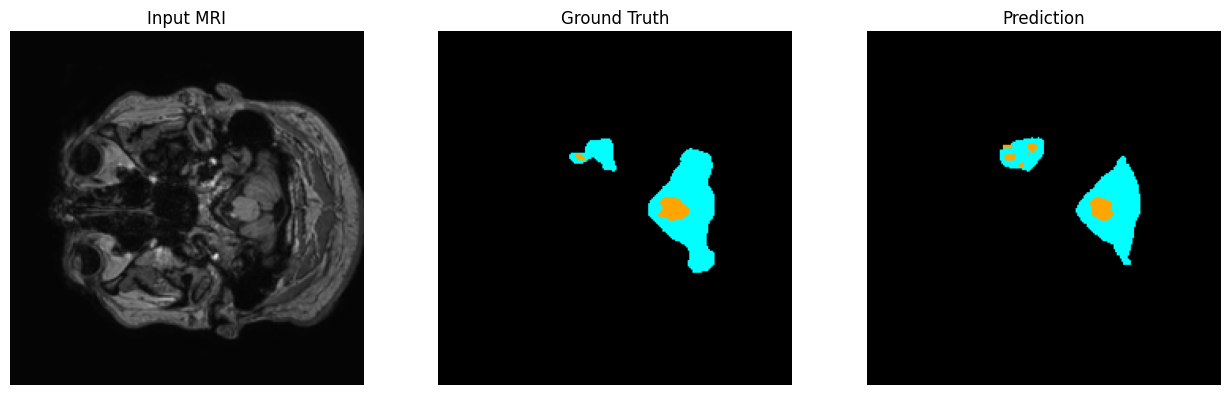

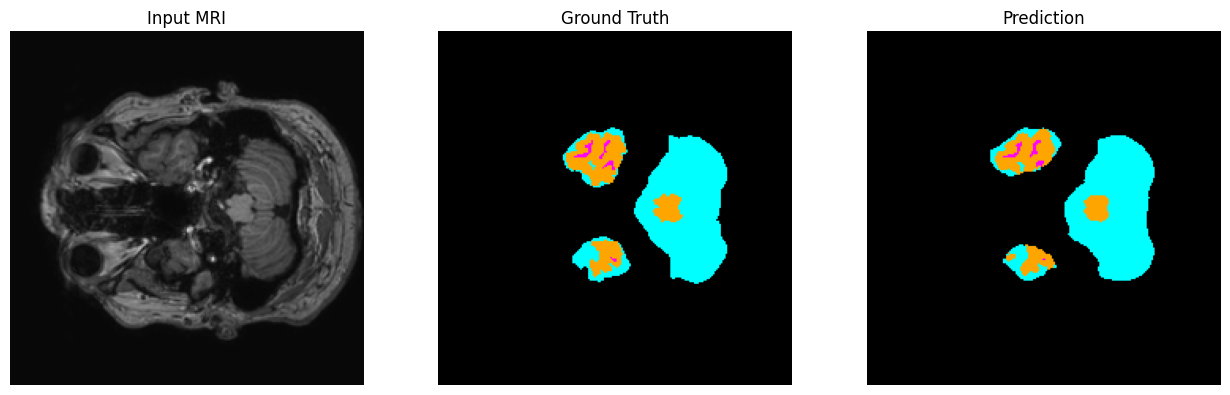

Prediction after epoch 70


Epoch 70: val_iou_score_multiclass did not improve from 0.77003
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 238ms/step - csf_iou: 0.3626 - dice_coefficient_multiclass: 0.3818 - gm_iou: 0.0055 - iou_score_multiclass: 0.3343 - loss: 0.6505 - pixel_accuracy_multiclass: 0.9995 - wm_iou: 5.6444e-04 - val_csf_iou: 0.7043 - val_dice_coefficient_multiclass: 0.8627 - val_gm_iou: 0.6712 - val_iou_score_multiclass: 0.7670 - val_loss: 0.2297 - val_pixel_accuracy_multiclass: 0.9707 - val_wm_iou: 0.7166 - learning_rate: 2.5000e-05
Epoch 71/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - csf_iou: 0.7121 - dice_coefficient_multiclass: 0.8178 - gm_iou: 0.6428 - iou_score_multiclass: 0.7218 - loss: 0.2601 - pixel_accuracy_multiclass: 0.9747 - wm_iou: 0.5548
Epoch 71: val_iou_score_multiclass improved from 0.77003 to 0.77058, saving model to best_model_vgg19unetpp_mrbrains.keras

Epoch 71: finished saving model to best_model_vgg19unetpp_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 605ms/ste

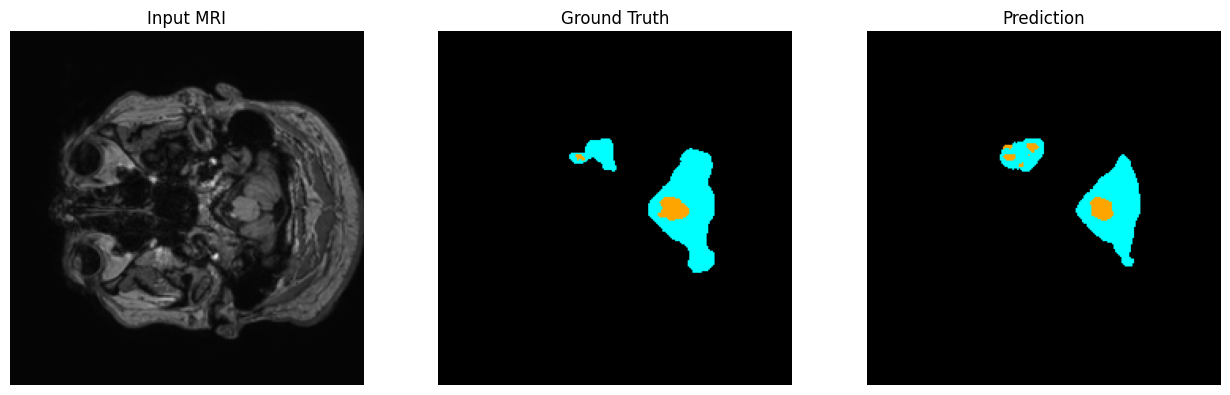

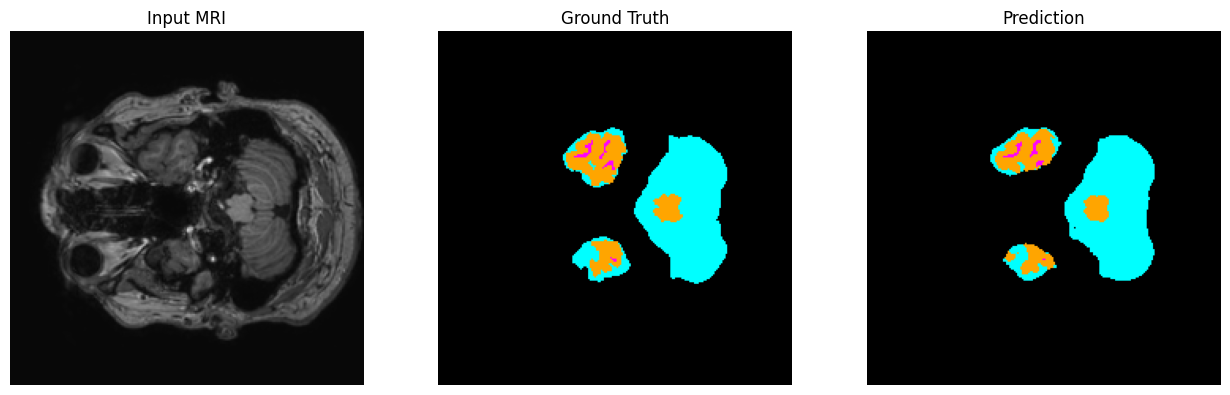

Prediction after epoch 80


Epoch 80: val_iou_score_multiclass did not improve from 0.77434
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 237ms/step - csf_iou: 0.3857 - dice_coefficient_multiclass: 0.3885 - gm_iou: 0.0057 - iou_score_multiclass: 0.3410 - loss: 0.6409 - pixel_accuracy_multiclass: 0.9994 - wm_iou: 6.3393e-04 - val_csf_iou: 0.7126 - val_dice_coefficient_multiclass: 0.8666 - val_gm_iou: 0.6769 - val_iou_score_multiclass: 0.7728 - val_loss: 0.2236 - val_pixel_accuracy_multiclass: 0.9709 - val_wm_iou: 0.7233 - learning_rate: 2.5000e-05
Epoch 81/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - csf_iou: 0.7221 - dice_coefficient_multiclass: 0.8253 - gm_iou: 0.6549 - iou_score_multiclass: 0.7310 - loss: 0.2496 - pixel_accuracy_multiclass: 0.9753 - wm_iou: 0.5676
Epoch 81: val_iou_score_multiclass improved from 0.77434 to 0.77481, saving model to best_model_vgg19unetpp_mrbrains.keras

Epoch 81: finished saving model to best_model_vgg19unetpp_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 604ms/ste

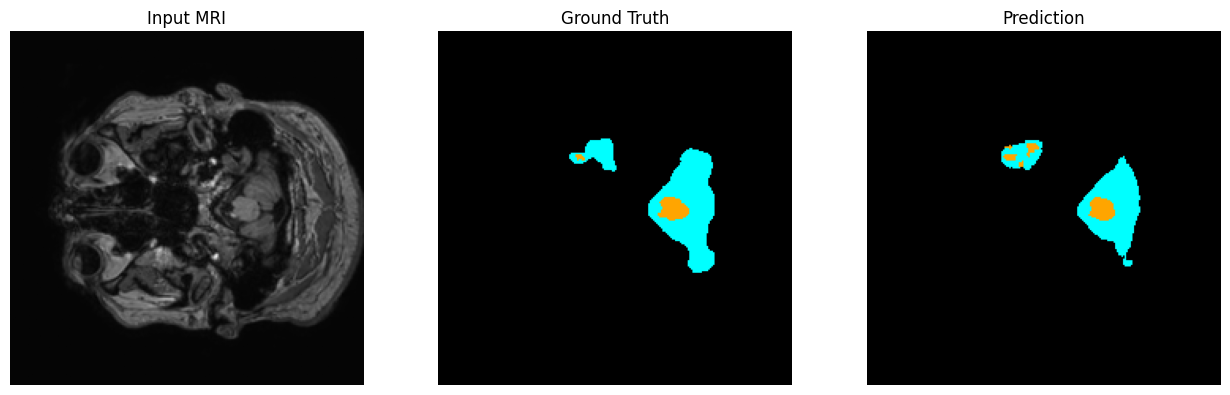

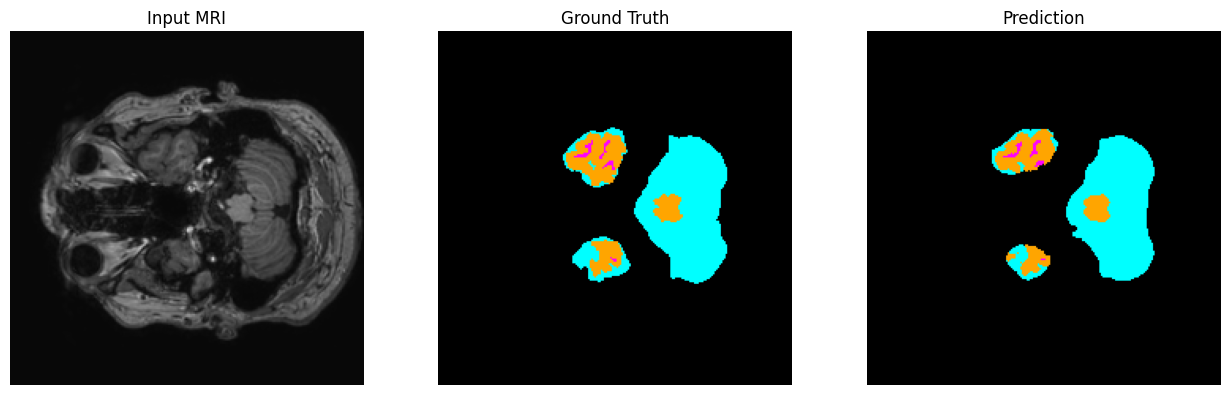

Prediction after epoch 90


Epoch 90: val_iou_score_multiclass did not improve from 0.77722
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 239ms/step - csf_iou: 0.4161 - dice_coefficient_multiclass: 0.3952 - gm_iou: 0.0030 - iou_score_multiclass: 0.3487 - loss: 0.6316 - pixel_accuracy_multiclass: 0.9994 - wm_iou: 7.1871e-04 - val_csf_iou: 0.7150 - val_dice_coefficient_multiclass: 0.8685 - val_gm_iou: 0.6802 - val_iou_score_multiclass: 0.7756 - val_loss: 0.2210 - val_pixel_accuracy_multiclass: 0.9709 - val_wm_iou: 0.7277 - learning_rate: 2.5000e-05
Epoch 91/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - csf_iou: 0.7297 - dice_coefficient_multiclass: 0.8320 - gm_iou: 0.6659 - iou_score_multiclass: 0.7391 - loss: 0.2407 - pixel_accuracy_multiclass: 0.9758 - wm_iou: 0.5799
Epoch 91: val_iou_score_multiclass improved from 0.77722 to 0.77863, saving model to best_model_vgg19unetpp_mrbrains.keras

Epoch 91: finished saving model to best_model_vgg19unetpp_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 602ms/ste

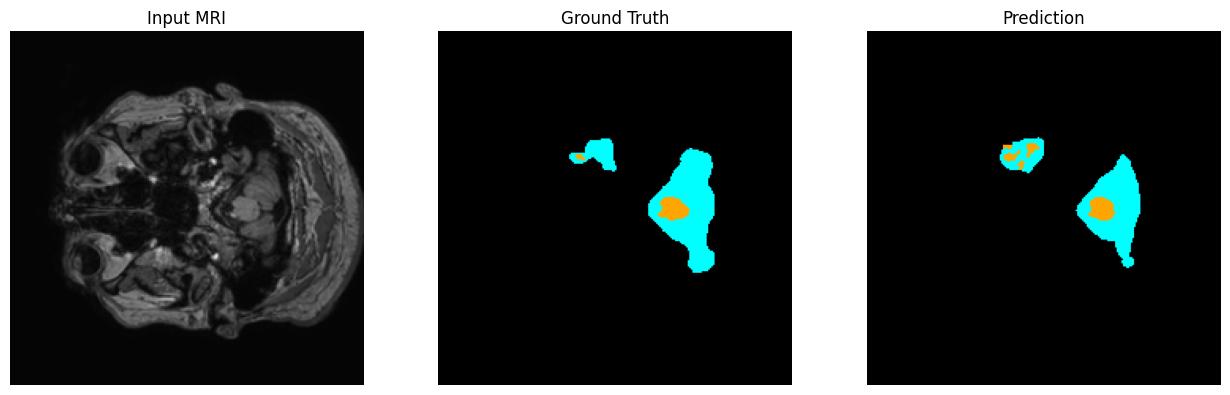

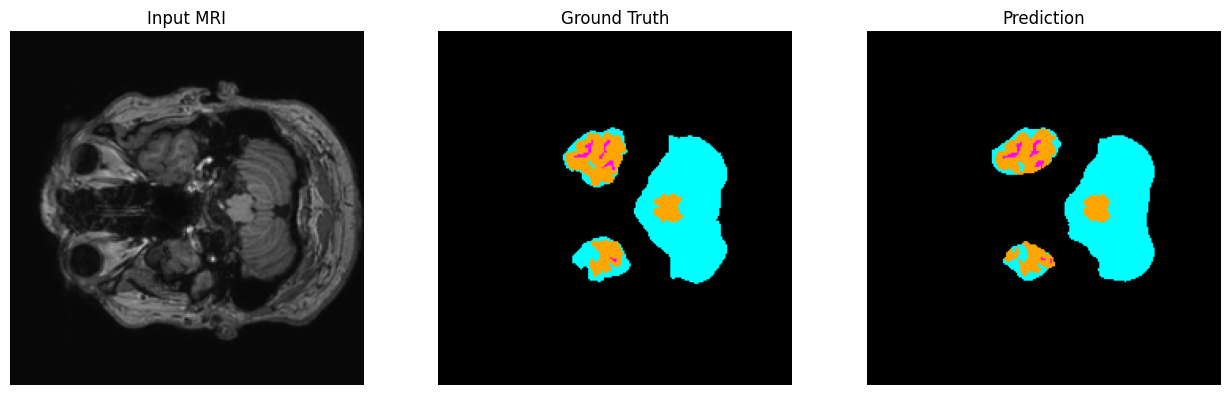

Prediction after epoch 100


Epoch 100: val_iou_score_multiclass did not improve from 0.78180
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 237ms/step - csf_iou: 0.4355 - dice_coefficient_multiclass: 0.4029 - gm_iou: 0.0082 - iou_score_multiclass: 0.3554 - loss: 0.6216 - pixel_accuracy_multiclass: 0.9994 - wm_iou: 7.8573e-04 - val_csf_iou: 0.7176 - val_dice_coefficient_multiclass: 0.8718 - val_gm_iou: 0.6841 - val_iou_score_multiclass: 0.7806 - val_loss: 0.2168 - val_pixel_accuracy_multiclass: 0.9712 - val_wm_iou: 0.7401 - learning_rate: 1.2500e-05

Training time: 23.9 min


In [23]:
steps_per_epoch  = max(1, len(os.listdir(TRAIN_IMG_DIR)) // BATCH_SIZE)
validation_steps = max(1, len(os.listdir(TEST_IMG_DIR))  // BATCH_SIZE)

print(f'Steps per epoch  : {steps_per_epoch}')
print(f'Validation steps : {validation_steps}')

start_time = time.time()
history = model.fit(
    train_dataset, validation_data=test_dataset, epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch, validation_steps=validation_steps,
    callbacks=callbacks_list
)
print(f'\nTraining time: {(time.time()-start_time)/60:.1f} min')

## 13. Training Graphs

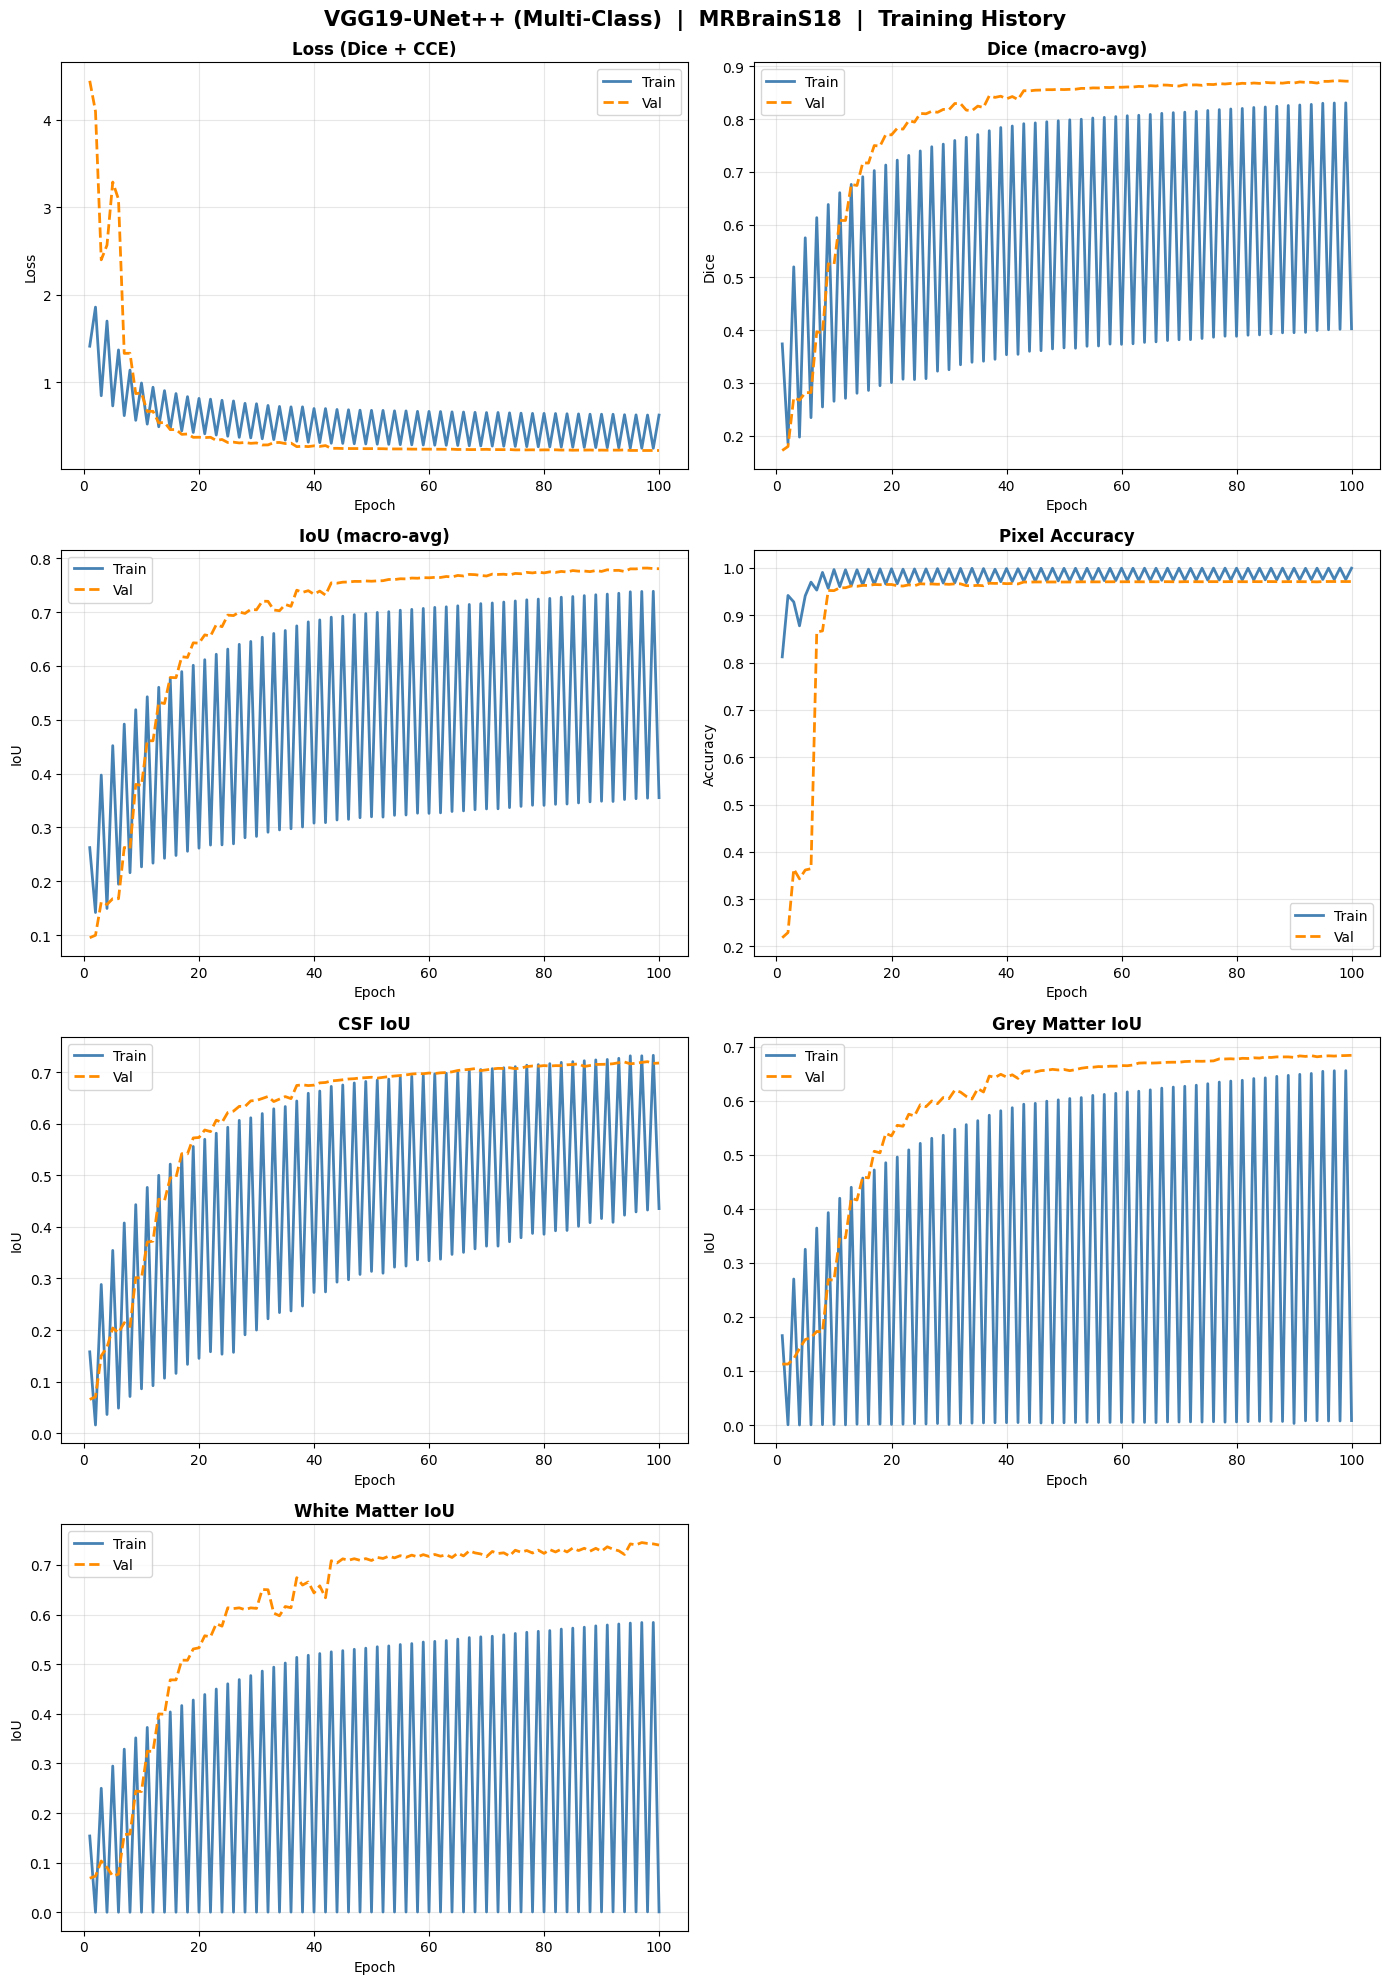

Plot saved ✓


In [24]:
H = history.history

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle('VGG19-UNet++ (Multi-Class)  |  MRBrainS18  |  Training History',
             fontsize=15, fontweight='bold', y=0.99)

plot_specs = [
    ('loss', 'val_loss', 'Loss (Dice + CCE)', 'Loss'),
    ('dice_coefficient_multiclass', 'val_dice_coefficient_multiclass', 'Dice (macro-avg)', 'Dice'),
    ('iou_score_multiclass', 'val_iou_score_multiclass', 'IoU (macro-avg)', 'IoU'),
    ('pixel_accuracy_multiclass', 'val_pixel_accuracy_multiclass', 'Pixel Accuracy', 'Accuracy'),
    ('csf_iou', 'val_csf_iou', 'CSF IoU', 'IoU'),
    ('gm_iou', 'val_gm_iou', 'Grey Matter IoU', 'IoU'),
    ('wm_iou', 'val_wm_iou', 'White Matter IoU', 'IoU'),
]

for ax, (tk, vk, title, ylabel) in zip(axes.flatten(), plot_specs):
    er = range(1, len(H[tk]) + 1)
    ax.plot(er, H[tk], label='Train', color='steelblue', linewidth=2)
    ax.plot(er, H[vk], label='Val', color='darkorange', linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.savefig('training_history_vgg19_unetpp_mrbrains.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ✓')

## 14. Best & Average Metrics Table

In [25]:
metric_spec = [
    ('Loss', 'loss', 'min'),
    ('Dice (macro-avg)', 'dice_coefficient_multiclass', 'max'),
    ('IoU (macro-avg)', 'iou_score_multiclass', 'max'),
    ('Pixel Accuracy', 'pixel_accuracy_multiclass', 'max'),
    ('CSF IoU', 'csf_iou', 'max'),
    ('Grey Matter IoU', 'gm_iou', 'max'),
    ('White Matter IoU', 'wm_iou', 'max'),
]

rows = []
for disp, key, mode in metric_spec:
    tr = np.asarray(H[key], dtype=np.float64)
    va = np.asarray(H['val_' + key], dtype=np.float64)
    pick = np.min if mode == 'min' else np.max
    rows.append({'Metric': disp, 'Train Best': pick(tr), 'Train Avg': tr.mean(),
                 'Val Best': pick(va), 'Val Avg': va.mean()})

report = pd.DataFrame(rows).set_index('Metric').round(4)

print('=' * 68)
print('   BEST & AVERAGE METRICS  —  VGG19-UNet++ Multi-Class  |  MRBrainS18')
print('=' * 68)
print(report.to_string())
print('=' * 68)
best_epoch = int(np.argmax(H['val_iou_score_multiclass'])) + 1
print(f'\nBest Val IoU (macro-avg): {max(H["val_iou_score_multiclass"]):.4f}  (epoch {best_epoch})')
print(f'Best Val CSF IoU         : {max(H["val_csf_iou"]):.4f}')
print(f'Best Val Grey Matter IoU : {max(H["val_gm_iou"]):.4f}')
print(f'Best Val White Matter IoU: {max(H["val_wm_iou"]):.4f}')
report

   BEST & AVERAGE METRICS  —  VGG19-UNet++ Multi-Class  |  MRBrainS18
                  Train Best  Train Avg  Val Best  Val Avg
Metric                                                    
Loss                  0.2423     0.5656    0.2165   0.4892
Dice (macro-avg)      0.8309     0.5538    0.8727   0.7848
IoU (macro-avg)       0.7387     0.4801    0.7818   0.6794
Pixel Accuracy        0.9997     0.9803    0.9713   0.9268
CSF IoU               0.7325     0.4533    0.7202   0.6173
Grey Matter IoU       0.6557     0.2817    0.6841   0.5855
White Matter IoU      0.5841     0.2489    0.7451   0.6134

Best Val IoU (macro-avg): 0.7818  (epoch 98)
Best Val CSF IoU         : 0.7202
Best Val Grey Matter IoU : 0.6841
Best Val White Matter IoU: 0.7451


,Train Best,Train Avg,Val Best,Val Avg
Metric,,,,
Loss,0.2423,0.5656,0.2165,0.4892
Dice (macro-avg),0.8309,0.5538,0.8727,0.7848
IoU (macro-avg),0.7387,0.4801,0.7818,0.6794
Pixel Accuracy,0.9997,0.9803,0.9713,0.9268
CSF IoU,0.7325,0.4533,0.7202,0.6173
Grey Matter IoU,0.6557,0.2817,0.6841,0.5855
White Matter IoU,0.5841,0.2489,0.7451,0.6134


## 15. Load Best Model & Final Evaluation

In [26]:
best_model = tf.keras.models.load_model(
    'best_model_vgg19unetpp_mrbrains.keras',
    custom_objects={
        'combined_loss_multiclass': combined_loss_multiclass,
        'dice_coefficient_multiclass': dice_coefficient_multiclass,
        'iou_score_multiclass': iou_score_multiclass,
        'pixel_accuracy_multiclass': pixel_accuracy_multiclass,
        'csf_iou': csf_iou, 'gm_iou': gm_iou, 'wm_iou': wm_iou,
    }
)
print('Best model loaded ✓')

Best model loaded ✓


In [27]:
test_results = best_model.evaluate(test_dataset, verbose=1)
test_dict = dict(zip(best_model.metrics_names, test_results))

print('\n' + '=' * 60)
print('  FINAL TEST-SET METRICS  (VGG19-UNet++ | MRBrainS18)')
print('=' * 60)
for k, v in test_dict.items():
    print(f'  {k:35s}: {v:.4f}')
print('=' * 60)

pd.DataFrame([{
    'Model': 'VGG19-UNet++ (MRBrainS18)',
    'IoU (macro)': round(test_dict.get('iou_score_multiclass', float('nan')), 4),
    'Dice (macro)': round(test_dict.get('dice_coefficient_multiclass', float('nan')), 4),
    'CSF IoU': round(test_dict.get('csf_iou', float('nan')), 4),
    'GM IoU': round(test_dict.get('gm_iou', float('nan')), 4),
    'WM IoU': round(test_dict.get('wm_iou', float('nan')), 4),
    'Pixel Accuracy': round(test_dict.get('pixel_accuracy_multiclass', float('nan')), 4),
}]).set_index('Model')

9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 402ms/step - csf_iou: 0.7252 - dice_coefficient_multiclass: 0.8693 - gm_iou: 0.6830 - iou_score_multiclass: 0.7774 - loss: 0.2155 - pixel_accuracy_multiclass: 0.9730 - wm_iou: 0.7204

  FINAL TEST-SET METRICS  (VGG19-UNet++ | MRBrainS18)
  loss                               : 0.2155
  compile_metrics                    : 0.8693


,IoU (macro),Dice (macro),CSF IoU,GM IoU,WM IoU,Pixel Accuracy
Model,,,,,,
VGG19-UNet++ (MRBrainS18),NaN,NaN,NaN,NaN,NaN,NaN


## 16. Test Predictions Visualization

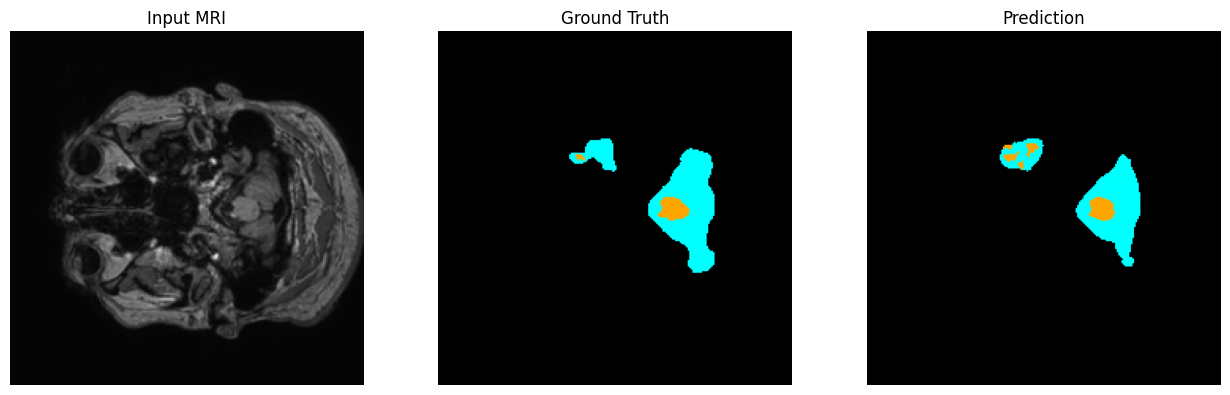

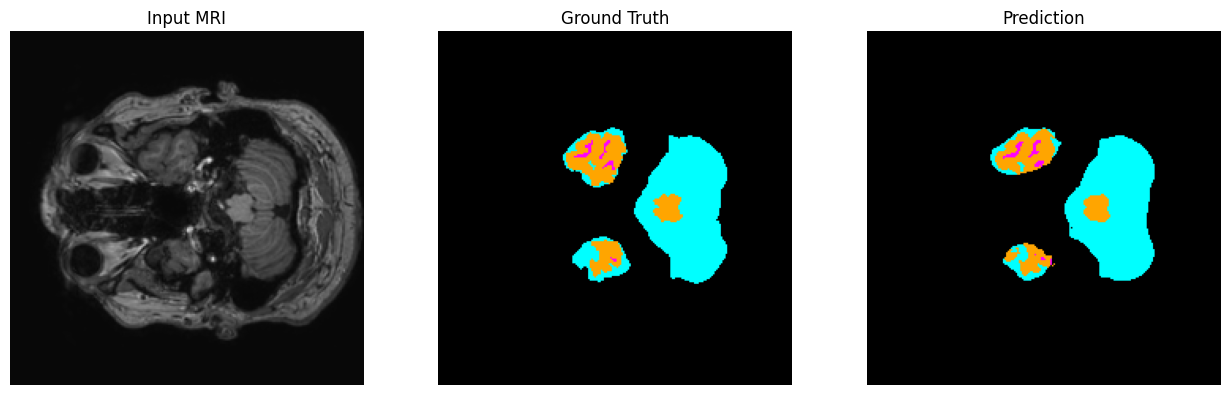

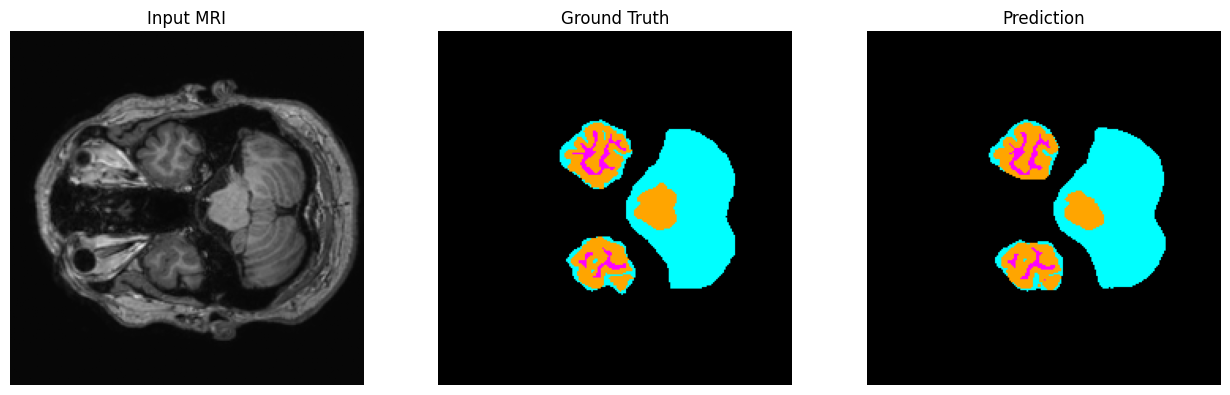

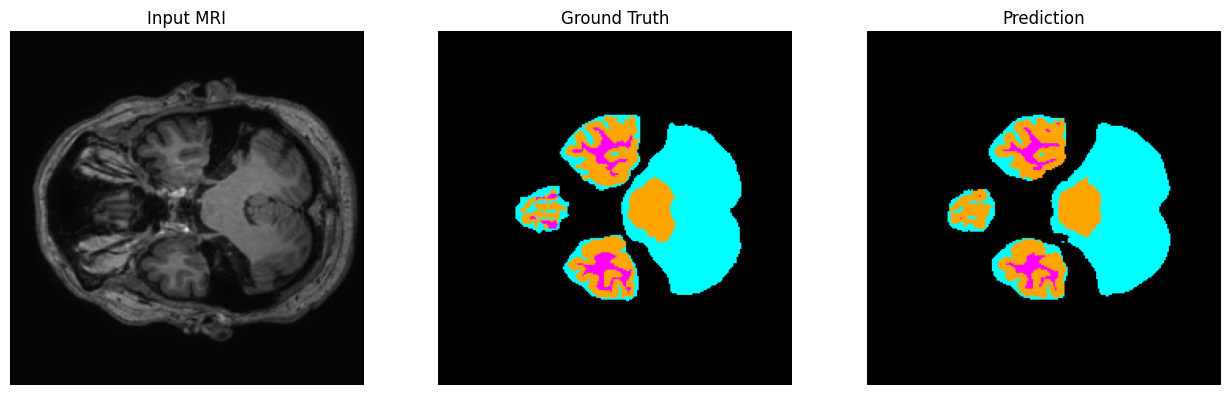

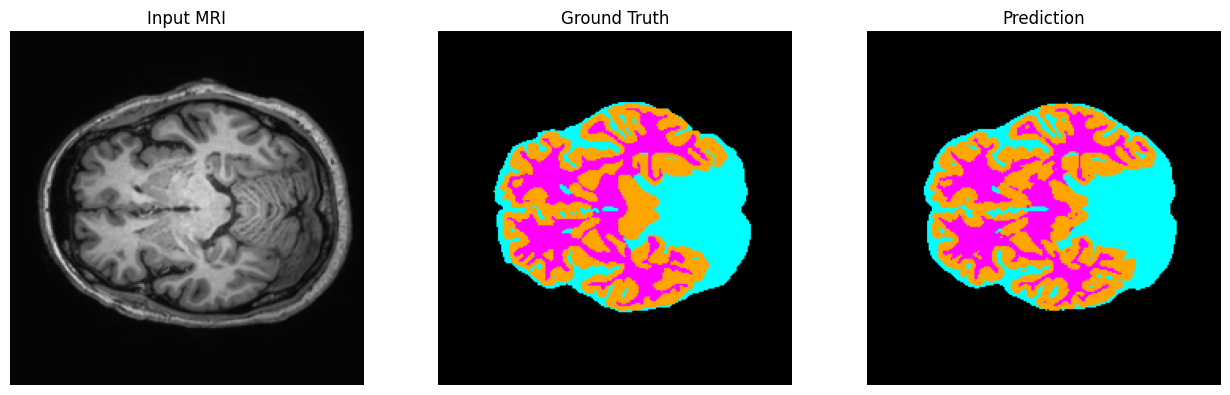

In [28]:
show_predictions(test_dataset, num=5, model_to_use=best_model)

## 17. Save Final Model

In [29]:
best_model.save('mrbrains_vgg19_unetpp_multiclass_final.keras')
print('Model saved ✓')

Model saved ✓
